# Task 3 — Gender and Occasion Classification with CNNs

**COSC2753 Assignment 2** ·

## The CNN flow, and where it appears in this notebook

| Course note | Implementation |
|---|---|
| A CNN has four blocks: convolution, non-linearity, pooling, fully-connected MLP | Section 2 builds each explicitly |
| The first three extract features; the MLP classifies | Every architecture separates `features` from `classifier` |
| Both parts must be trained together | One optimiser over all parameters; nothing is frozen or trained separately |
| Flatten the final feature map into the MLP | `nn.Flatten()` in every model. Global average pooling is tested afterwards as a documented alternative, not as the default |
| SoftMax at the output | See the note on logits in Section 2 |
| Decide batch size, kernel size and count, activation | Section 3 makes each choice per architecture and explains it |
| Study LeNet, AlexNet, VGGNet, GoogLeNet, ResNet | Section 3 implements all five and compares them |
| Do not branch a shared feature map into separate MLP heads at the end | Section 4 tests exactly this claim and follows the advice |

## The multi-task question from the notes

The Q&A says that taking one final feature map and splitting it into separate MLP heads reduces
the network to a plain MLP, because the feature extraction is no longer tied to any single
classification. The advice is to design the multi-task structure from the start.

Section 4 builds both and measures them:

* **Late branching** — one shared trunk, split after the final feature map (the pattern warned about)
* **Early branching** — shared low-level convolutions, then a **separate convolutional pathway
  per task**, each with its own flatten and MLP (the pattern advised)

Early branching means the deeper filters for `gender` are trained only on gender, and those for
`usage` only on usage, so feature extraction stays tied to each classification.

## Why softmax does not appear in the model code

The notes say to apply SoftMax at the output. In PyTorch, `nn.CrossEntropyLoss` applies
`log_softmax` internally for numerical stability, so the network returns raw **logits** during
training. Softmax is applied explicitly whenever probabilities are needed — see Section 7. The
mathematics is identical; applying it twice would be the error.

## 1. Setup and data

In [2]:
# ============================================
# CELL 1 - Imports, device, reproducibility
# ============================================

import os
import json
import time
import copy
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42


def set_seed(seed=RANDOM_STATE):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATASET_ROOT = PROJECT_DIR / "A2_FashionDataset"
PROCESSED_DIR = DATASET_ROOT / "processed"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "task3_cnn"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    # --- image ---
    "image_width": 60, "image_height": 80, "channels": 3,

    # --- targets ---
    "targets": ["gender", "usage"],
    "min_class_size": 100,

    # --- one of the decisions the notes ask for ---
    "batch_size": 128,

    # --- training ---
    "max_epochs": 30,
    "early_stopping_patience": 6,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "num_workers": 0,          # keep 0 on Windows/Jupyter

    # --- splitting ---
    "test_fraction": 0.15, "val_fraction": 0.15,
    "group_column": "productDisplayName",
}
IMAGE_SIZE_PIL = (CONFIG["image_width"], CONFIG["image_height"])
IMAGE_SHAPE = (CONFIG["image_height"], CONFIG["image_width"], 3)
INPUT_SHAPE = (3, CONFIG["image_height"], CONFIG["image_width"])   # C, H, W
print(json.dumps(CONFIG, indent=2))

PyTorch: 2.11.0+cu128 | Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
{
  "image_width": 60,
  "image_height": 80,
  "channels": 3,
  "targets": [
    "gender",
    "usage"
  ],
  "min_class_size": 100,
  "batch_size": 128,
  "max_epochs": 30,
  "early_stopping_patience": 6,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "num_workers": 0,
  "test_fraction": 0.15,
  "val_fraction": 0.15,
  "group_column": "productDisplayName"
}


In [3]:
# ============================================
# CELL 2 - Load metadata, resolve labels
# ============================================

data = pd.read_csv(PROCESSED_DIR / "clean_train_metadata.csv")
print("Rows:", len(data))

model_df = data[data["usage"].notna() & data["gender"].notna()].copy()
print(f"Dropped {len(data) - len(model_df)} rows with a missing target label")

# Rare `usage` values are merged into the nearest sensible class rather than
# pooled into a meaningless 'Other' bucket (see 01_eda.ipynb for the comparison).
USAGE_MERGE = {"Smart Casual": "Casual", "Travel": "Casual", "Party": "Formal"}
model_df = model_df[model_df["usage"] != "Home"].copy()
model_df["usage_label"] = model_df["usage"].replace(USAGE_MERGE)
model_df["gender_label"] = model_df["gender"]

from sklearn.preprocessing import LabelEncoder

encoders, class_names = {}, {}
for target in CONFIG["targets"]:
    encoder = LabelEncoder()
    model_df[target + "_y"] = encoder.fit_transform(model_df[target + "_label"].astype(str))
    encoders[target] = encoder
    class_names[target] = list(encoder.classes_)
    print(f"{target:8s} -> {len(encoder.classes_)} classes: {list(encoder.classes_)}")

NUM_CLASSES = {t: len(encoders[t].classes_) for t in CONFIG["targets"]}
model_df = model_df.reset_index(drop=True)
print("\nRows used:", len(model_df))

Rows: 38612
Dropped 72 rows with a missing target label
gender   -> 5 classes: ['Boys', 'Girls', 'Men', 'Unisex', 'Women']
usage    -> 4 classes: ['Casual', 'Ethnic', 'Formal', 'Sports']

Rows used: 38539


In [4]:
# ============================================
# CELL 3 - Baselines, grouped split, image cache
# ============================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold

BASELINE = {}
for target in CONFIG["targets"]:
    y = model_df[target + "_y"].values
    dummy = DummyClassifier(strategy="most_frequent").fit(np.zeros((len(y), 1)), y)
    pred = dummy.predict(np.zeros((len(y), 1)))
    BASELINE[target] = {"accuracy": accuracy_score(y, pred) * 100,
                        "macro_f1": f1_score(y, pred, average="macro", zero_division=0) * 100}
    print(f"{target:8s} majority baseline: {BASELINE[target]['accuracy']:.2f}% accuracy, "
          f"{BASELINE[target]['macro_f1']:.2f} macro-F1")

# Grouped so near-duplicate photos of one product cannot straddle the split.
model_df["_strat"] = model_df["gender_label"] + "|" + model_df["usage_label"]
counts = model_df["_strat"].value_counts()
model_df.loc[model_df["_strat"].isin(counts[counts < 10].index), "_strat"] = "RARE"
groups = model_df[CONFIG["group_column"]].fillna(model_df["id"].astype(str))


def grouped_split(df, strat, grp, fraction, seed=RANDOM_STATE):
    splitter = StratifiedGroupKFold(n_splits=max(2, int(round(1 / fraction))),
                                    shuffle=True, random_state=seed)
    keep, hold = next(splitter.split(df, strat, grp))
    return df.iloc[keep], df.iloc[hold]


trainval_df, test_df = grouped_split(model_df, model_df["_strat"], groups,
                                     CONFIG["test_fraction"])
tv_groups = trainval_df[CONFIG["group_column"]].fillna(trainval_df["id"].astype(str))
train_df, val_df = grouped_split(trainval_df, trainval_df["_strat"], tv_groups,
                                 CONFIG["val_fraction"] / (1 - CONFIG["test_fraction"]))

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:6s} {len(part):>6d}")
for a, b, label in [(train_df, val_df, "train/val"), (train_df, test_df, "train/test"),
                    (val_df, test_df, "val/test")]:
    overlap = set(a[CONFIG["group_column"]].fillna("")) & set(b[CONFIG["group_column"]].fillna(""))
    assert not overlap, f"leakage in {label}"
print("No product appears in more than one split.")

# --- image cache ---
CACHE_X = PROCESSED_DIR / f"task3cnn_cache_{CONFIG['image_width']}x{CONFIG['image_height']}.npy"
CACHE_IDS = CACHE_X.with_name(CACHE_X.stem + "_ids.npy")


def load_image_array(path, size=IMAGE_SIZE_PIL):
    with Image.open(path) as img:
        return np.asarray(img.convert("RGB").resize(size, Image.BILINEAR), dtype=np.uint8)


ids = model_df["id"].to_numpy()
if CACHE_X.exists() and CACHE_IDS.exists() and len(np.load(CACHE_IDS)) == len(ids) \
        and (np.load(CACHE_IDS) == ids).all():
    IMAGES = np.load(CACHE_X, mmap_mode="r")
    print("Loaded image cache:", IMAGES.shape)
else:
    print("Building image cache ...")
    IMAGES = np.lib.format.open_memmap(CACHE_X, mode="w+", dtype=np.uint8,
                                       shape=(len(model_df),) + IMAGE_SHAPE)
    for position, path in enumerate(model_df["image_path"]):
        IMAGES[position] = load_image_array(path)
        if (position + 1) % 10000 == 0:
            print(f"  {position + 1}/{len(model_df)}")
    IMAGES.flush(); np.save(CACHE_IDS, ids)

position_of = {image_id: position for position, image_id in enumerate(ids)}
for part in (train_df, val_df, test_df):
    part["pos"] = part["id"].map(position_of).astype(int)

gender   majority baseline: 54.20% accuracy, 14.06 macro-F1
usage    majority baseline: 77.11% accuracy, 21.77 macro-F1
train   27527
val      5506
test     5506
No product appears in more than one split.
Loaded image cache: (38539, 80, 60, 3)


In [5]:
# ============================================
# CELL 4 - Dataset and loaders
# ============================================

sample = np.asarray(IMAGES[train_df["pos"].sample(min(4000, len(train_df)),
                    random_state=RANDOM_STATE).sort_values().to_numpy()],
                    dtype=np.float32) / 255.0
CHANNEL_MEAN = sample.mean(axis=(0, 1, 2)); CHANNEL_STD = sample.std(axis=(0, 1, 2))
del sample
MEAN_T = torch.tensor(CHANNEL_MEAN, dtype=torch.float32).view(3, 1, 1)
STD_T = torch.tensor(CHANNEL_STD, dtype=torch.float32).view(3, 1, 1)
print("channel mean:", CHANNEL_MEAN.round(4), "| std:", CHANNEL_STD.round(4))


class FashionDataset(Dataset):
    def __init__(self, frame):
        self.positions = frame["pos"].to_numpy()
        self.gender = frame["gender_y"].to_numpy()
        self.usage = frame["usage_y"].to_numpy()

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, index):
        array = np.asarray(IMAGES[self.positions[index]], dtype=np.float32) / 255.0
        tensor = (torch.from_numpy(array.transpose(2, 0, 1)) - MEAN_T) / STD_T
        return tensor, int(self.gender[index]), int(self.usage[index])


def make_loader(frame, shuffle=False, batch_size=None):
    return DataLoader(FashionDataset(frame),
                      batch_size=batch_size or CONFIG["batch_size"],
                      shuffle=shuffle, num_workers=CONFIG["num_workers"],
                      pin_memory=(DEVICE.type == "cuda"))


train_loader = make_loader(train_df, shuffle=True)
val_loader = make_loader(val_df)
test_loader = make_loader(test_df)

images, gender, usage = next(iter(train_loader))
print("batch:", images.shape, "| gender:", gender.shape, "| usage:", usage.shape)
print("Classes:", NUM_CLASSES)

channel mean: [0.8547 0.836  0.8269] | std: [0.2537 0.2589 0.2597]
batch: torch.Size([128, 3, 80, 60]) | gender: torch.Size([128]) | usage: torch.Size([128])
Classes: {'gender': 5, 'usage': 4}


## 2. The four building blocks

Written out separately so each maps onto the course notes.

**1. Convolution.** A small kernel slides across the image and computes a weighted sum at every
position. The same weights are reused everywhere, so a filter that detects a collar detects it
wherever the collar appears. Kernel *size* sets how much context one neuron sees; kernel *count*
sets how many different patterns the layer can detect.

**2. Non-linearity.** Without it, stacked convolutions collapse into a single linear map and
depth buys nothing. `tanh` was standard in LeNet; it saturates at both ends, so gradients vanish
in deep stacks. `ReLU` (AlexNet onward) is zero for negatives and identity for positives, so
gradients pass unchanged through active units — which is what made deep networks trainable.
Sigmoid has the same saturation problem as tanh and is now used only for binary outputs.

**3. Pooling.** Downsamples the feature map, which shrinks computation and grants small
translation invariance. Max-pooling keeps the strongest response in each window (best for "is
this pattern present?"); average pooling keeps the mean (smoother, used in LeNet).

**4. Fully-connected MLP.** The feature map is flattened into a vector and passed through dense
layers to the class scores. This is the classifier; everything before it is the feature extractor.

Both parts are trained together by a single optimiser, so the filters are shaped by the
classification loss rather than by some separate objective.

In [6]:
# ============================================
# CELL 5 - The four blocks, written explicitly
# ============================================

demo_input = torch.zeros(1, *INPUT_SHAPE)
print("input                       ", tuple(demo_input.shape))

# 1. convolution
conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2)
x = conv(demo_input)
print("after Conv2d(3->16, k=5)    ", tuple(x.shape),
      f"| {sum(p.numel() for p in conv.parameters()):,} parameters")

# 2. non-linearity
x = F.relu(x)
print("after ReLU                  ", tuple(x.shape), "(shape unchanged)")

# 3. pooling
x = F.max_pool2d(x, 2)
print("after MaxPool2d(2)          ", tuple(x.shape), "(spatial size halved)")

# 4. flatten -> fully connected
flat = x.flatten(1)
print("after Flatten               ", tuple(flat.shape))
head = nn.Linear(flat.shape[1], 5)
print("after Linear(-> 5 classes)  ", tuple(head(flat).shape), "= logits")

print()
print("Softmax turns those logits into probabilities:")
print(F.softmax(head(flat), dim=1).detach().numpy().round(3))
print()
print("During training the model returns logits and nn.CrossEntropyLoss applies")
print("log_softmax internally - mathematically the same, numerically safer.")

input                        (1, 3, 80, 60)
after Conv2d(3->16, k=5)     (1, 16, 80, 60) | 1,216 parameters
after ReLU                   (1, 16, 80, 60) (shape unchanged)
after MaxPool2d(2)           (1, 16, 40, 30) (spatial size halved)
after Flatten                (1, 19200)
after Linear(-> 5 classes)   (1, 5) = logits

Softmax turns those logits into probabilities:
[[0.195 0.2   0.2   0.206 0.2  ]]

During training the model returns logits and nn.CrossEntropyLoss applies
log_softmax internally - mathematically the same, numerically safer.


In [7]:
# ============================================
# CELL 6 - Helper: infer the flattened size automatically
# ============================================

def flat_features(feature_extractor, input_shape=INPUT_SHAPE):
    """Run one dummy image through the feature extractor to find the flatten size.

    Hard-coding this number is the classic source of shape bugs when an
    architecture is adapted to a new input resolution, so it is measured instead.
    """
    was_training = feature_extractor.training
    feature_extractor.eval()
    with torch.no_grad():
        output = feature_extractor(torch.zeros(1, *input_shape))
    feature_extractor.train(was_training)
    return int(np.prod(output.shape[1:])), tuple(output.shape[1:])


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("Input resolution:", INPUT_SHAPE, "(C, H, W)")
print("Every architecture below is adapted to this size, because the originals")
print("were designed for 32x32 (LeNet) or 224x224 (the rest).")

Input resolution: (3, 80, 60) (C, H, W)
Every architecture below is adapted to this size, because the originals
were designed for 32x32 (LeNet) or 224x224 (the rest).


## 3. Established architectures

Five landmark designs, each adapted to 60x80 input. The point is not to reproduce them exactly
— they were built for different image sizes and for 1000-class ImageNet — but to understand
**why each made the choices it did**, which is what the notes ask for.

| Architecture | Year | The idea it introduced | Activation | Pooling |
|---|---|---|---|---|
| **LeNet-5** | 1998 | convolution + pooling + MLP is enough to read digits | tanh | average |
| **AlexNet** | 2012 | depth, ReLU and dropout, trained on a GPU | ReLU | max |
| **VGGNet** | 2014 | stack small 3x3 kernels instead of using large ones | ReLU | max |
| **GoogLeNet** | 2014 | look at several kernel sizes in parallel (Inception) | ReLU | max + concat |
| **ResNet** | 2015 | skip connections, so depth stops hurting | ReLU | max/stride |

### Why the kernels differ

**LeNet uses 5x5** because the network is only two convolutional layers deep; each layer must
see a reasonably wide patch on its own.

**AlexNet opens with a large stride-2 kernel** purely to shrink a 224x224 image quickly — a cost
saving, not a modelling insight.

**VGG replaced every large kernel with stacked 3x3s.** Two 3x3 layers see the same 5x5 receptive
field as one 5x5 layer, but use 2x(9C^2) weights instead of 25C^2 — fewer parameters, and an
extra non-linearity in between. This is the most transferable lesson of the five, and it is why
the deeper models here are all 3x3.

**GoogLeNet refuses to choose**: each Inception module runs 1x1, 3x3 and 5x5 convolutions plus a
pooling branch in parallel and concatenates them, letting the network learn which scale matters.
The 1x1 convolutions reduce channel count first, which keeps the cost manageable.

**ResNet adds `output = F(x) + x`.** Beyond roughly 20 layers, plain stacks get *worse* on
training data — an optimisation failure, not overfitting. The skip connection gives gradients a
direct path backwards, so extra layers can at worst learn to do nothing.

In [8]:
# ============================================
# CELL 7 - LeNet-5 (1998)
# ============================================

class LeNetFeatures(nn.Module):
    """Two convolutional stages with tanh and average pooling, as in the paper."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5, padding=2),   # padding keeps the size
            nn.Tanh(),
            nn.AvgPool2d(2),
            nn.Conv2d(6, 16, kernel_size=5),             # no padding, as in LeNet-5
            nn.Tanh(),
            nn.AvgPool2d(2),
        )

    def forward(self, x):
        return self.net(x)


features = LeNetFeatures()
size, shape = flat_features(features)
print(f"LeNet feature map {shape} -> flattened {size}")
print(f"feature extractor parameters: {count_parameters(features):,}")
print()
print("tanh and average pooling are period-accurate. Both are now unusual: tanh")
print("saturates, and max pooling generally beats average for detecting whether a")
print("pattern is present. The ablation in Section 6 tests the activation choice.")

LeNet feature map (16, 18, 13) -> flattened 3744
feature extractor parameters: 2,872

tanh and average pooling are period-accurate. Both are now unusual: tanh
saturates, and max pooling generally beats average for detecting whether a
pattern is present. The ablation in Section 6 tests the activation choice.


In [9]:
# ============================================
# CELL 8 - AlexNet-style (2012)
# ============================================

class AlexNetFeatures(nn.Module):
    """Scaled-down AlexNet: five convolutions, ReLU, overlapping max pooling.

    The original's 11x11 stride-4 first layer assumes a 224x224 input; at 60x80 it
    would destroy the image, so a 7x7 stride-2 layer plays the same role.
    """

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 48, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(48),                 # modern stand-in for local response norm
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2),

            nn.Conv2d(48, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2),

            nn.Conv2d(128, 192, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(192, 192, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(192, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2),
        )

    def forward(self, x):
        return self.net(x)


features = AlexNetFeatures()
size, shape = flat_features(features)
print(f"AlexNet feature map {shape} -> flattened {size}")
print(f"feature extractor parameters: {count_parameters(features):,}")
print()
print("AlexNet's contributions were ReLU (trains far faster than tanh), dropout in")
print("the classifier, and the demonstration that GPUs made this depth practical.")

AlexNet feature map (128, 4, 2) -> flattened 1024
feature extractor parameters: 935,840

AlexNet's contributions were ReLU (trains far faster than tanh), dropout in
the classifier, and the demonstration that GPUs made this depth practical.


In [10]:
# ============================================
# CELL 9 - VGG-style (2014)
# ============================================

class VGGFeatures(nn.Module):
    """Blocks of two 3x3 convolutions then max-pool, doubling the channel count."""

    def __init__(self, widths=(32, 64, 128, 256)):
        super().__init__()
        layers, in_channels = [], 3
        for width in widths:
            layers += [
                nn.Conv2d(in_channels, width, 3, padding=1, bias=False),
                nn.BatchNorm2d(width), nn.ReLU(inplace=True),
                nn.Conv2d(width, width, 3, padding=1, bias=False),
                nn.BatchNorm2d(width), nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            ]
            in_channels = width
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


features = VGGFeatures()
size, shape = flat_features(features)
print(f"VGG feature map {shape} -> flattened {size}")
print(f"feature extractor parameters: {count_parameters(features):,}")
print()
print("Two stacked 3x3 layers cover the same 5x5 receptive field as one 5x5 layer")
print("with fewer weights and an extra non-linearity - VGG's central argument.")
print("Channels double whenever the spatial size halves, keeping the compute per")
print("block roughly constant while representations get more abstract.")

VGG feature map (256, 5, 3) -> flattened 3840
feature extractor parameters: 1,173,216

Two stacked 3x3 layers cover the same 5x5 receptive field as one 5x5 layer
with fewer weights and an extra non-linearity - VGG's central argument.
Channels double whenever the spatial size halves, keeping the compute per
block roughly constant while representations get more abstract.


In [11]:
# ============================================
# CELL 10 - GoogLeNet / Inception (2014)
# ============================================

class InceptionModule(nn.Module):
    """Four parallel branches, concatenated: 1x1, 3x3, 5x5 and pooling.

    The 1x1 convolutions in front of the 3x3 and 5x5 branches reduce the channel
    count first. Without them a 5x5 convolution over many channels dominates the
    cost of the whole network.
    """

    def __init__(self, in_channels, out_1x1, reduce_3x3, out_3x3,
                 reduce_5x5, out_5x5, pool_proj):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, out_1x1, 1), nn.BatchNorm2d(out_1x1), nn.ReLU(True))
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, reduce_3x3, 1), nn.BatchNorm2d(reduce_3x3), nn.ReLU(True),
            nn.Conv2d(reduce_3x3, out_3x3, 3, padding=1), nn.BatchNorm2d(out_3x3), nn.ReLU(True))
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, reduce_5x5, 1), nn.BatchNorm2d(reduce_5x5), nn.ReLU(True),
            nn.Conv2d(reduce_5x5, out_5x5, 5, padding=2), nn.BatchNorm2d(out_5x5), nn.ReLU(True))
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, 1), nn.BatchNorm2d(pool_proj), nn.ReLU(True))

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x),
                          self.branch3(x), self.branch4(x)], dim=1)


class GoogLeNetFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2),
            InceptionModule(32, 16, 16, 32, 8, 16, 16),      # -> 80 channels
            nn.MaxPool2d(2),
            InceptionModule(80, 32, 32, 64, 16, 32, 32),     # -> 160 channels
            nn.MaxPool2d(2),
            InceptionModule(160, 64, 48, 96, 16, 48, 48),    # -> 256 channels
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.net(x)


features = GoogLeNetFeatures()
size, shape = flat_features(features)
print(f"GoogLeNet feature map {shape} -> flattened {size}")
print(f"feature extractor parameters: {count_parameters(features):,}")
print()
print("Rather than committing to one kernel size per layer, each module looks at")
print("several scales at once and lets training decide which to rely on. Note the")
print("parameter count relative to VGG - the 1x1 reductions are doing real work.")

GoogLeNet feature map (256, 5, 3) -> flattened 3840
feature extractor parameters: 141,448

Rather than committing to one kernel size per layer, each module looks at
several scales at once and lets training decide which to rely on. Note the
parameter count relative to VGG - the 1x1 reductions are doing real work.


In [12]:
# ============================================
# CELL 11 - ResNet-style (2015)
# ============================================

class ResidualBlock(nn.Module):
    """Two 3x3 convolutions plus a shortcut: out = F(x) + x.

    When the shape changes, the shortcut needs a 1x1 convolution so the two
    tensors can be added.
    """

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))      # the skip connection


class ResNetFeatures(nn.Module):
    def __init__(self, widths=(32, 64, 128, 256), blocks_per_stage=2):
        super().__init__()
        layers = [nn.Conv2d(3, widths[0], 3, padding=1, bias=False),
                  nn.BatchNorm2d(widths[0]), nn.ReLU(True)]
        in_channels = widths[0]
        for stage, width in enumerate(widths):
            for block in range(blocks_per_stage):
                stride = 2 if block == 0 else 1        # halve the map once per stage
                layers.append(ResidualBlock(in_channels, width, stride))
                in_channels = width
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


features = ResNetFeatures()
size, shape = flat_features(features)
print(f"ResNet feature map {shape} -> flattened {size}")
print(f"feature extractor parameters: {count_parameters(features):,}")
print()
print("Adding depth to a plain stack eventually raises TRAINING error, which is an")
print("optimisation failure rather than overfitting. The identity shortcut means an")
print("unnecessary block can learn to output zero and pass its input through.")

ResNet feature map (256, 5, 4) -> flattened 5120
feature extractor parameters: 2,796,128

Adding depth to a plain stack eventually raises TRAINING error, which is an
optimisation failure rather than overfitting. The identity shortcut means an
unnecessary block can learn to output zero and pass its input through.


## 4. The multi-task question from the notes

> *Can I take one final feature map and use it to classify several different attributes?*
> *Not by branching at the very end... design the multi-task structure from the start instead.*

Two designs, so the claim can be tested rather than assumed.

### Design A — late branching (the pattern the notes warn about)

```
image -> [ shared conv stack ] -> flatten -> MLP -> gender
                               \-> flatten -> MLP -> usage
```

Every convolutional filter is shared. The gradient reaching a filter is the sum of both tasks'
gradients, so no filter is specialised to either. This is what the notes describe as reducing
the arrangement to a plain MLP on top of generic features.

### Design B — early branching (the pattern the notes recommend)

```
                          /-> [ gender conv blocks ] -> flatten -> MLP -> gender
image -> [ shared blocks ]
                          \-> [ usage  conv blocks ] -> flatten -> MLP -> usage
```

Only the low-level layers are shared — edges, colours and textures, which genuinely are common
to both tasks. The deeper blocks are **separate convolutional pathways**, so the filters that
detect "formal tailoring" are trained by the usage loss alone, and feature extraction stays tied
to each classification.

### Also worth knowing

Design B costs more parameters and compute, because the deep layers exist twice. Section 5
measures whether the accuracy justifies it.

In [13]:
# ============================================
# CELL 12 - Classifier head: flatten -> MLP -> logits
# ============================================

def make_classifier(in_features, n_classes, hidden=256, dropout=0.5):
    """The MLP from the course notes: flatten, dense, non-linearity, dense.

    Dropout is AlexNet's contribution to the classifier - the dense layers hold
    most of the parameters and overfit first.
    """
    return nn.Sequential(
        nn.Flatten(),
        nn.Dropout(dropout),
        nn.Linear(in_features, hidden),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(hidden, n_classes),        # logits; softmax applied at prediction time
    )


class LateBranchNet(nn.Module):
    """Design A - one shared feature extractor, one MLP per task."""

    def __init__(self, feature_factory, num_classes, hidden=256, dropout=0.5):
        super().__init__()
        self.features = feature_factory()
        flat, self.feature_shape = flat_features(self.features)
        self.heads = nn.ModuleDict({
            target: make_classifier(flat, n, hidden, dropout)
            for target, n in num_classes.items()
        })

    def forward(self, x):
        shared = self.features(x)
        return {target: head(shared) for target, head in self.heads.items()}


class EarlyBranchNet(nn.Module):
    """Design B - shared low-level blocks, then a conv pathway per task."""

    def __init__(self, num_classes, shared_widths=(32, 64), branch_widths=(128, 256),
                 hidden=256, dropout=0.5):
        super().__init__()

        def vgg_block(in_channels, width):
            return [nn.Conv2d(in_channels, width, 3, padding=1, bias=False),
                    nn.BatchNorm2d(width), nn.ReLU(inplace=True),
                    nn.Conv2d(width, width, 3, padding=1, bias=False),
                    nn.BatchNorm2d(width), nn.ReLU(inplace=True),
                    nn.MaxPool2d(2)]

        layers, in_channels = [], 3
        for width in shared_widths:
            layers += vgg_block(in_channels, width)
            in_channels = width
        self.shared = nn.Sequential(*layers)
        shared_channels = in_channels

        self.branches = nn.ModuleDict()
        self.heads = nn.ModuleDict()
        for target, n_classes in num_classes.items():
            branch_layers, channels = [], shared_channels
            for width in branch_widths:
                branch_layers += vgg_block(channels, width)
                channels = width
            branch = nn.Sequential(*branch_layers)
            self.branches[target] = branch

            # flat_features() switches to eval() first: a batch of one through a
            # freshly built BatchNorm in training mode raises "Expected more than
            # 1 value per channel".
            flat, _ = flat_features(nn.Sequential(self.shared, branch))
            self.heads[target] = make_classifier(flat, n_classes, hidden, dropout)

    def forward(self, x):
        shared = self.shared(x)
        return {target: self.heads[target](self.branches[target](shared))
                for target in self.branches}


probe_a = LateBranchNet(VGGFeatures, NUM_CLASSES)
probe_b = EarlyBranchNet(NUM_CLASSES)
print(f"Design A (late branching) : {count_parameters(probe_a):>10,} parameters")
print(f"Design B (early branching): {count_parameters(probe_b):>10,} parameters")
print(f"Design B costs {count_parameters(probe_b) / count_parameters(probe_a):.2f}x as much")
del probe_a, probe_b

Design A (late branching) :  3,142,121 parameters
Design B (early branching):  4,249,577 parameters
Design B costs 1.35x as much


## 5. Training and evaluation

In [14]:
# ============================================
# CELL 13 - Metrics
# ============================================

from sklearn.metrics import classification_report, confusion_matrix


def compute_metrics(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred) * 100,
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
            "balanced_acc": balanced_accuracy_score(y_true, y_pred) * 100}


@torch.no_grad()
def predict(model, loader):
    model.eval()
    active = list(model.heads.keys())
    store = {t: {"true": [], "pred": [], "prob": []} for t in active}
    for images, gender, usage in loader:
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        truth = {"gender": gender, "usage": usage}
        for target in active:
            logits = outputs[target].float()
            store[target]["true"].append(truth[target].numpy())
            store[target]["pred"].append(logits.argmax(1).cpu().numpy())
            # softmax here, exactly as the course notes describe
            store[target]["prob"].append(F.softmax(logits, dim=1).cpu().numpy())
    return {t: {k: np.concatenate(v) for k, v in store[t].items()} for t in active}


def summarise(predictions):
    present = [t for t in CONFIG["targets"] if t in predictions]
    result = {t: compute_metrics(predictions[t]["true"], predictions[t]["pred"])
              for t in present}
    if len(present) == 2:
        both = ((predictions["gender"]["true"] == predictions["gender"]["pred"]) &
                (predictions["usage"]["true"] == predictions["usage"]["pred"]))
        result["exact_match"] = both.mean() * 100
    else:
        result["exact_match"] = np.nan
    result["mean_macro_f1"] = float(np.mean([result[t]["macro_f1"] for t in present]))
    result["targets"] = present
    return result

In [15]:
# ============================================
# CELL 14 - Training loop
# ============================================

def train_model(model, tag, loader_train=None, loader_val=None, config=None, verbose=True):
    """Feature extractor and classifier are optimised together, as the notes require."""
    cfg = {**CONFIG, **(config or {})}
    loader_train = loader_train or train_loader
    loader_val = loader_val or val_loader
    model = model.to(DEVICE)
    active = list(model.heads.keys())

    criterion = nn.CrossEntropyLoss()          # applies log_softmax internally
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"],
                                  weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                           factor=0.5, patience=3)
    history, best = [], {"score": -np.inf, "state": None, "epoch": -1, "stale": 0}
    started = time.time()

    for epoch in range(cfg["max_epochs"]):
        model.train()
        running, seen = 0.0, 0
        for images, gender, usage in loader_train:
            images = images.to(DEVICE, non_blocking=True)
            targets = {"gender": gender.to(DEVICE), "usage": usage.to(DEVICE)}

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = sum(criterion(outputs[t], targets[t]) for t in active)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            running += loss.item() * images.size(0); seen += images.size(0)

        val = summarise(predict(model, loader_val))
        score = val["mean_macro_f1"]
        scheduler.step(score)
        history.append({"epoch": epoch + 1, "train_loss": running / seen,
                        "val_mean_f1": score,
                        "val_gender_f1": val.get("gender", {}).get("macro_f1", np.nan),
                        "val_usage_f1": val.get("usage", {}).get("macro_f1", np.nan)})

        if score > best["score"] + 1e-4:
            best = {"score": score, "state": copy.deepcopy(model.state_dict()),
                    "epoch": epoch + 1, "stale": 0}
        else:
            best["stale"] += 1

        if verbose and ((epoch + 1) % 5 == 0 or epoch == 0 or best["stale"] == 0):
            print(f"  [{tag}] epoch {epoch + 1:>2}/{cfg['max_epochs']} "
                  f"loss {history[-1]['train_loss']:.4f} val mean-F1 {score:.2f}"
                  f"{'  <- best' if best['stale'] == 0 else ''}")

        if best["stale"] >= cfg["early_stopping_patience"]:
            if verbose:
                print(f"  [{tag}] early stop at epoch {epoch + 1}")
            break

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    if verbose:
        print(f"  [{tag}] best {best['score']:.2f} at epoch {best['epoch']} "
              f"({(time.time() - started) / 60:.1f} min)")
    return model, pd.DataFrame(history)


RESULTS, MODELS, HISTORIES = {}, {}, {}


def run(tag, build, config=None):
    set_seed()
    model, history = train_model(build(), tag, config=config)
    summary = summarise(predict(model, val_loader))
    RESULTS[tag], MODELS[tag], HISTORIES[tag] = summary, model, history
    # Single-task controls have only one head, so report whichever are present.
    parts = [f"{t} F1 {summary[t]['macro_f1']:.2f}" for t in summary["targets"]]
    parts.append(f"mean {summary['mean_macro_f1']:.2f}")
    if not np.isnan(summary["exact_match"]):
        parts.append(f"exact {summary['exact_match']:.2f}")
    parts.append(f"{count_parameters(model):,} params")
    print(f"{tag:16s} " + " | ".join(parts))
    return model

In [16]:
# ============================================
# CELL 15 - Train all five architectures (Design A)
# ============================================

ARCHITECTURES = {
    "LeNet": LeNetFeatures,
    "AlexNet": AlexNetFeatures,
    "VGG": VGGFeatures,
    "GoogLeNet": GoogLeNetFeatures,
    "ResNet": ResNetFeatures,
}

for name, factory in ARCHITECTURES.items():
    print(f"\n=== {name} ===")
    run(name, lambda f=factory: LateBranchNet(f, NUM_CLASSES))


=== LeNet ===
  [LeNet] epoch  1/30 loss 1.1197 val mean-F1 63.48  <- best
  [LeNet] epoch  2/30 loss 0.8734 val mean-F1 69.66  <- best
  [LeNet] epoch  3/30 loss 0.7953 val mean-F1 73.07  <- best
  [LeNet] epoch  4/30 loss 0.7450 val mean-F1 73.91  <- best
  [LeNet] epoch  5/30 loss 0.6960 val mean-F1 73.78
  [LeNet] epoch  6/30 loss 0.6704 val mean-F1 75.58  <- best
  [LeNet] epoch  9/30 loss 0.5873 val mean-F1 76.21  <- best
  [LeNet] epoch 10/30 loss 0.5709 val mean-F1 76.33  <- best
  [LeNet] epoch 12/30 loss 0.5346 val mean-F1 76.41  <- best
  [LeNet] epoch 13/30 loss 0.5151 val mean-F1 77.40  <- best
  [LeNet] epoch 15/30 loss 0.4861 val mean-F1 76.94
  [LeNet] epoch 17/30 loss 0.4561 val mean-F1 77.68  <- best
  [LeNet] epoch 18/30 loss 0.4511 val mean-F1 78.73  <- best
  [LeNet] epoch 20/30 loss 0.4288 val mean-F1 77.88
  [LeNet] epoch 24/30 loss 0.3593 val mean-F1 78.81  <- best
  [LeNet] epoch 25/30 loss 0.3516 val mean-F1 79.10  <- best
  [LeNet] epoch 27/30 loss 0.3361 va

,Architecture,GenderF1,UsageF1,MeanF1,ExactMatch,GenderAcc,UsageAcc,Params,Epochs
2,VGG,78.96,83.41,81.18,81.06,89.87,90.36,3142121,30
3,GoogLeNet,79.65,82.30,80.98,80.64,89.88,89.67,2110353,30
0,LeNet,78.03,81.50,79.77,80.37,89.65,89.67,1922625,30
1,AlexNet,76.91,81.76,79.33,79.77,89.12,89.54,1462953,27
4,ResNet,77.11,80.31,78.71,78.62,88.54,88.49,5420393,30


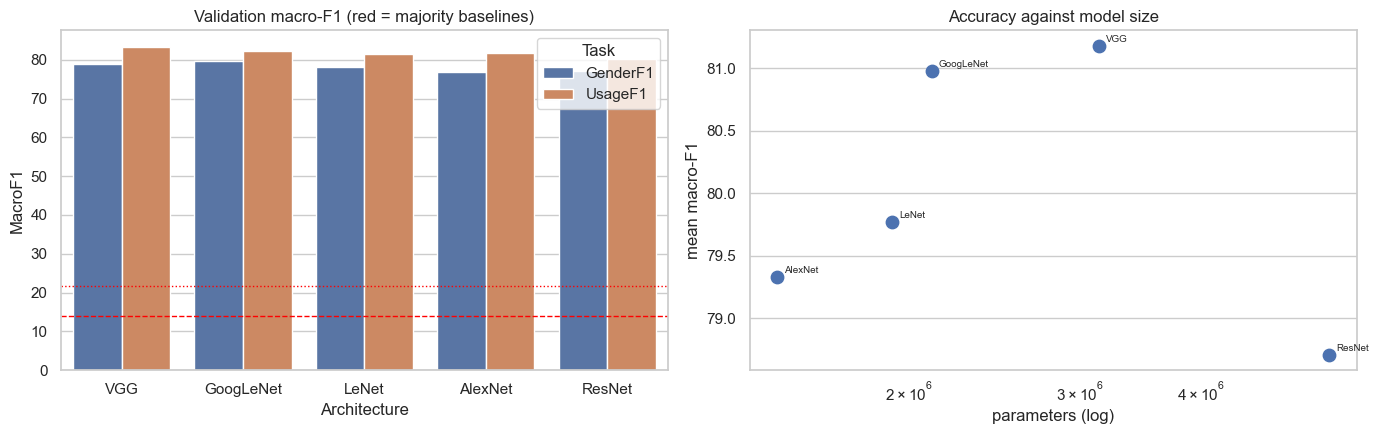

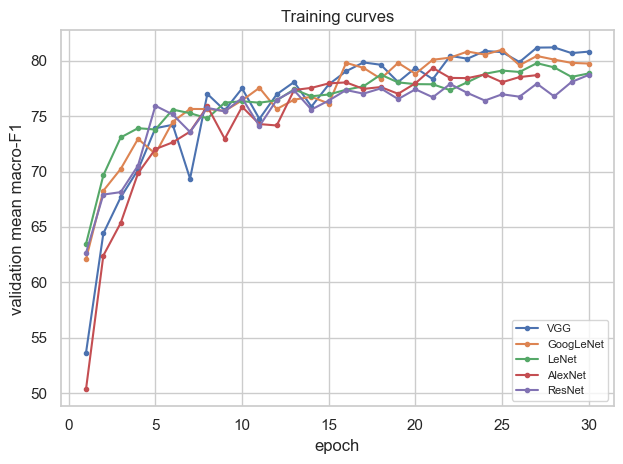

In [17]:
# ============================================
# CELL 16 - Compare the architectures
# ============================================

overview = pd.DataFrame([
    {"Architecture": name,
     "GenderF1": round(RESULTS[name]["gender"]["macro_f1"], 2),
     "UsageF1": round(RESULTS[name]["usage"]["macro_f1"], 2),
     "MeanF1": round(RESULTS[name]["mean_macro_f1"], 2),
     "ExactMatch": round(RESULTS[name]["exact_match"], 2),
     "GenderAcc": round(RESULTS[name]["gender"]["accuracy"], 2),
     "UsageAcc": round(RESULTS[name]["usage"]["accuracy"], 2),
     "Params": count_parameters(MODELS[name]),
     "Epochs": len(HISTORIES[name])}
    for name in ARCHITECTURES if name in RESULTS
]).sort_values("MeanF1", ascending=False)
display(overview)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_data = overview.melt(id_vars="Architecture", value_vars=["GenderF1", "UsageF1"],
                          var_name="Task", value_name="MacroF1")
sns.barplot(data=plot_data, x="Architecture", y="MacroF1", hue="Task", ax=axes[0])
axes[0].axhline(BASELINE["gender"]["macro_f1"], ls="--", color="red", lw=1)
axes[0].axhline(BASELINE["usage"]["macro_f1"], ls=":", color="red", lw=1)
axes[0].set_title("Validation macro-F1 (red = majority baselines)")

axes[1].scatter(overview["Params"], overview["MeanF1"], s=80)
for _, row in overview.iterrows():
    axes[1].annotate(row["Architecture"], (row["Params"], row["MeanF1"]),
                     fontsize=7, xytext=(5, 3), textcoords="offset points")
axes[1].set_xscale("log"); axes[1].set_xlabel("parameters (log)")
axes[1].set_ylabel("mean macro-F1"); axes[1].set_title("Accuracy against model size")
plt.tight_layout(); plt.show()

for name in overview["Architecture"]:
    plt.plot(HISTORIES[name]["epoch"], HISTORIES[name]["val_mean_f1"], marker=".", label=name)
plt.xlabel("epoch"); plt.ylabel("validation mean macro-F1")
plt.title("Training curves"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 6. Testing the design decisions

Three questions from the notes, each answered by changing one thing and measuring.

1. **Late or early branching?** The notes say late branching weakens feature learning.
2. **Flatten or global average pooling?** The notes say flatten. Modern architectures
   (GoogLeNet, ResNet) use global average pooling instead, so it is worth measuring.
3. **tanh or ReLU?** LeNet used tanh; everything after 2012 uses ReLU.

In [18]:
# ============================================
# CELL 17 - Late vs early branching, plus single-task controls
# ============================================

print("=== Design B: early branching ===")
run("EarlyBranch", lambda: EarlyBranchNet(NUM_CLASSES))

# Single-task controls: one network per attribute, no sharing at all. This is the
# ceiling for "feature extraction fully tied to one classification".
for target in CONFIG["targets"]:
    print(f"\n=== single task: {target} ===")
    run(f"Single_{target}", lambda t=target: LateBranchNet(VGGFeatures, {t: NUM_CLASSES[t]}))

=== Design B: early branching ===
  [EarlyBranch] epoch  1/30 loss 1.3179 val mean-F1 56.17  <- best
  [EarlyBranch] epoch  2/30 loss 0.9338 val mean-F1 68.21  <- best
  [EarlyBranch] epoch  3/30 loss 0.8055 val mean-F1 68.85  <- best
  [EarlyBranch] epoch  4/30 loss 0.7280 val mean-F1 72.39  <- best
  [EarlyBranch] epoch  5/30 loss 0.6696 val mean-F1 70.42
  [EarlyBranch] epoch  6/30 loss 0.6215 val mean-F1 73.97  <- best
  [EarlyBranch] epoch  7/30 loss 0.5858 val mean-F1 76.07  <- best
  [EarlyBranch] epoch  8/30 loss 0.5443 val mean-F1 77.71  <- best
  [EarlyBranch] epoch  9/30 loss 0.5119 val mean-F1 77.91  <- best
  [EarlyBranch] epoch 10/30 loss 0.4790 val mean-F1 76.45
  [EarlyBranch] epoch 12/30 loss 0.4092 val mean-F1 78.54  <- best
  [EarlyBranch] epoch 14/30 loss 0.3321 val mean-F1 78.88  <- best
  [EarlyBranch] epoch 15/30 loss 0.3093 val mean-F1 77.79
  [EarlyBranch] epoch 16/30 loss 0.2750 val mean-F1 79.68  <- best
  [EarlyBranch] epoch 20/30 loss 0.1667 val mean-F1 79.

,Target,Single-task,Late branch (A),Early branch (B),B - A,A - single
0,gender,79.77,78.96,80.27,1.30,-0.81
1,usage,81.42,83.41,83.09,-0.32,1.99


,Parameters
Late branch (A),3142121
Early branch (B),4249577
Two single-task nets,4315337


Reading this table:
 * 'B - A' positive  -> early branching helps, as the course notes predict.
 * 'A - single' positive -> sharing helped anyway, despite the warning;
   the shared filters were useful to both tasks rather than diluted.
 * Compare the gain against the parameter cost before choosing.


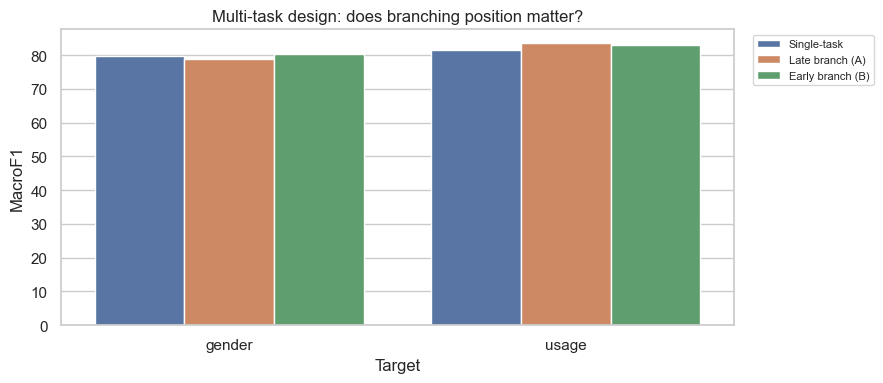

In [19]:
# ============================================
# CELL 18 - Does the notes' warning hold?
# ============================================

rows = []
for target in CONFIG["targets"]:
    single = RESULTS[f"Single_{target}"][target]["macro_f1"]
    late = RESULTS["VGG"][target]["macro_f1"]
    early = RESULTS["EarlyBranch"][target]["macro_f1"]
    rows.append({"Target": target,
                 "Single-task": round(single, 2),
                 "Late branch (A)": round(late, 2),
                 "Early branch (B)": round(early, 2),
                 "B - A": round(early - late, 2),
                 "A - single": round(late - single, 2)})
branching = pd.DataFrame(rows)
display(branching)

params = {"Late branch (A)": count_parameters(MODELS["VGG"]),
          "Early branch (B)": count_parameters(MODELS["EarlyBranch"]),
          "Two single-task nets": sum(count_parameters(MODELS[f"Single_{t}"])
                                      for t in CONFIG["targets"])}
display(pd.Series(params).to_frame("Parameters"))

print("Reading this table:")
print(" * 'B - A' positive  -> early branching helps, as the course notes predict.")
print(" * 'A - single' positive -> sharing helped anyway, despite the warning;")
print("   the shared filters were useful to both tasks rather than diluted.")
print(" * Compare the gain against the parameter cost before choosing.")

fig, ax = plt.subplots(figsize=(9, 4))
plot_data = branching.melt(id_vars="Target",
                           value_vars=["Single-task", "Late branch (A)", "Early branch (B)"],
                           var_name="Design", value_name="MacroF1")
sns.barplot(data=plot_data, x="Target", y="MacroF1", hue="Design", ax=ax)
ax.set_title("Multi-task design: does branching position matter?")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

In [20]:
# ============================================
# CELL 19 - Flatten vs global average pooling
# ============================================

class GAPNet(nn.Module):
    """Same VGG features, but average each channel to a single number instead of
    flattening. GoogLeNet introduced this: it removes almost all of the classifier's
    parameters, which is a strong regulariser, at the cost of discarding *where* in
    the frame each feature fired."""

    def __init__(self, feature_factory, num_classes, hidden=256, dropout=0.5):
        super().__init__()
        self.features = feature_factory()
        _, shape = flat_features(self.features)
        channels = shape[0]
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.heads = nn.ModuleDict({
            target: nn.Sequential(nn.Flatten(), nn.Dropout(dropout),
                                  nn.Linear(channels, hidden), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(hidden, n))
            for target, n in num_classes.items()})

    def forward(self, x):
        pooled = self.pool(self.features(x))
        return {target: head(pooled) for target, head in self.heads.items()}


print("=== global average pooling instead of flatten ===")
run("VGG_GAP", lambda: GAPNet(VGGFeatures, NUM_CLASSES))

comparison = pd.DataFrame([
    {"Head": "Flatten -> MLP (course notes)",
     "MeanF1": round(RESULTS["VGG"]["mean_macro_f1"], 2),
     "ExactMatch": round(RESULTS["VGG"]["exact_match"], 2),
     "Params": count_parameters(MODELS["VGG"])},
    {"Head": "Global average pooling -> MLP",
     "MeanF1": round(RESULTS["VGG_GAP"]["mean_macro_f1"], 2),
     "ExactMatch": round(RESULTS["VGG_GAP"]["exact_match"], 2),
     "Params": count_parameters(MODELS["VGG_GAP"])},
])
display(comparison)
print("Flatten keeps spatial position, which matters when an attribute depends on")
print("*where* something appears. Pooling throws that away but removes most of the")
print("classifier's weights. Which wins is an empirical question at this scale.")

=== global average pooling instead of flatten ===
  [VGG_GAP] epoch  1/30 loss 1.2182 val mean-F1 30.09  <- best
  [VGG_GAP] epoch  2/30 loss 0.8730 val mean-F1 61.76  <- best
  [VGG_GAP] epoch  4/30 loss 0.6873 val mean-F1 71.69  <- best
  [VGG_GAP] epoch  5/30 loss 0.6437 val mean-F1 70.32
  [VGG_GAP] epoch  6/30 loss 0.6053 val mean-F1 73.88  <- best
  [VGG_GAP] epoch  7/30 loss 0.5636 val mean-F1 74.76  <- best
  [VGG_GAP] epoch  9/30 loss 0.5048 val mean-F1 76.55  <- best
  [VGG_GAP] epoch 10/30 loss 0.4627 val mean-F1 59.81
  [VGG_GAP] epoch 12/30 loss 0.3885 val mean-F1 76.95  <- best
  [VGG_GAP] epoch 15/30 loss 0.2894 val mean-F1 68.36
  [VGG_GAP] epoch 17/30 loss 0.1559 val mean-F1 78.28  <- best
  [VGG_GAP] epoch 18/30 loss 0.1187 val mean-F1 79.10  <- best
  [VGG_GAP] epoch 20/30 loss 0.0941 val mean-F1 78.92
  [VGG_GAP] epoch 23/30 loss 0.0359 val mean-F1 80.48  <- best
  [VGG_GAP] epoch 25/30 loss 0.0246 val mean-F1 78.92
  [VGG_GAP] epoch 28/30 loss 0.0116 val mean-F1 80

,Head,MeanF1,ExactMatch,Params
0,Flatten -> MLP (course notes),81.18,81.06,3142121
1,Global average pooling -> MLP,80.76,81.47,1307113


Flatten keeps spatial position, which matters when an attribute depends on
*where* something appears. Pooling throws that away but removes most of the
classifier's weights. Which wins is an empirical question at this scale.


=== VGG with tanh activations ===
  [VGG_tanh] epoch  1/30 loss 1.2961 val mean-F1 58.37  <- best
  [VGG_tanh] epoch  2/30 loss 1.0102 val mean-F1 61.63  <- best
  [VGG_tanh] epoch  3/30 loss 0.9086 val mean-F1 65.45  <- best
  [VGG_tanh] epoch  4/30 loss 0.8518 val mean-F1 65.50  <- best
  [VGG_tanh] epoch  5/30 loss 0.7945 val mean-F1 68.10  <- best
  [VGG_tanh] epoch  7/30 loss 0.7349 val mean-F1 70.45  <- best
  [VGG_tanh] epoch  8/30 loss 0.7098 val mean-F1 72.28  <- best
  [VGG_tanh] epoch  9/30 loss 0.6831 val mean-F1 74.98  <- best
  [VGG_tanh] epoch 10/30 loss 0.6676 val mean-F1 70.01
  [VGG_tanh] epoch 14/30 loss 0.5454 val mean-F1 77.08  <- best
  [VGG_tanh] epoch 15/30 loss 0.5211 val mean-F1 76.36
  [VGG_tanh] epoch 16/30 loss 0.5100 val mean-F1 77.24  <- best
  [VGG_tanh] epoch 18/30 loss 0.4743 val mean-F1 77.80  <- best
  [VGG_tanh] epoch 19/30 loss 0.4679 val mean-F1 78.49  <- best
  [VGG_tanh] epoch 20/30 loss 0.4601 val mean-F1 76.79
  [VGG_tanh] epoch 22/30 loss 0.4

,Activation,MeanF1,Epochs
0,ReLU,81.18,30
1,tanh,80.87,30


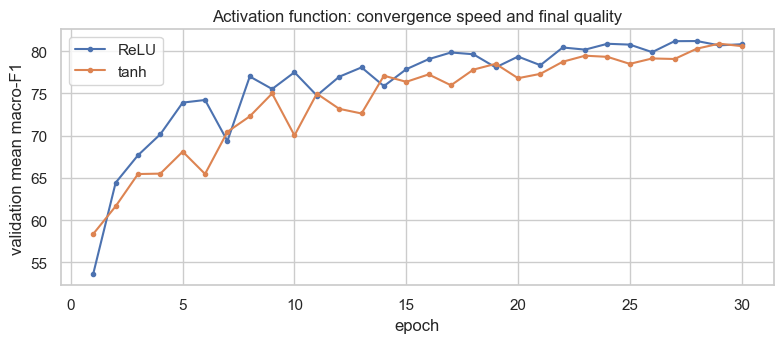

tanh saturates for large positive or negative inputs, so its gradient
approaches zero and deep stacks learn slowly. ReLU passes gradient
unchanged wherever the unit is active - the reason it replaced tanh in 2012.


In [21]:
# ============================================
# CELL 20 - tanh vs ReLU
# ============================================

class VGGTanh(VGGFeatures):
    """Identical VGG stack with every ReLU replaced by tanh, as LeNet used."""

    def __init__(self, widths=(32, 64, 128, 256)):
        super().__init__(widths)
        for name, module in list(self.net.named_children()):
            if isinstance(module, nn.ReLU):
                self.net[int(name)] = nn.Tanh()


print("=== VGG with tanh activations ===")
run("VGG_tanh", lambda: LateBranchNet(VGGTanh, NUM_CLASSES))

activation = pd.DataFrame([
    {"Activation": "ReLU", "MeanF1": round(RESULTS["VGG"]["mean_macro_f1"], 2),
     "Epochs": len(HISTORIES["VGG"])},
    {"Activation": "tanh", "MeanF1": round(RESULTS["VGG_tanh"]["mean_macro_f1"], 2),
     "Epochs": len(HISTORIES["VGG_tanh"])},
])
display(activation)

plt.figure(figsize=(8, 3.6))
for tag, label in [("VGG", "ReLU"), ("VGG_tanh", "tanh")]:
    plt.plot(HISTORIES[tag]["epoch"], HISTORIES[tag]["val_mean_f1"], marker=".", label=label)
plt.xlabel("epoch"); plt.ylabel("validation mean macro-F1")
plt.title("Activation function: convergence speed and final quality")
plt.legend(); plt.tight_layout(); plt.show()

print("tanh saturates for large positive or negative inputs, so its gradient")
print("approaches zero and deep stacks learn slowly. ReLU passes gradient")
print("unchanged wherever the unit is active - the reason it replaced tanh in 2012.")

## 7. Final model and test evaluation

In [22]:
# ============================================
# CELL 21 - Select on validation, evaluate once on test
# ============================================

candidates = {name: RESULTS[name]["mean_macro_f1"] for name in RESULTS
              if not name.startswith("Single_")}
selection = pd.DataFrame([
    {"Model": name,
     "ValMeanF1": round(score, 2),
     "ExactMatch": round(RESULTS[name]["exact_match"], 2),
     "Params": count_parameters(MODELS[name])}
    for name, score in candidates.items()
]).sort_values("ValMeanF1", ascending=False)
display(selection)

# Differences smaller than the sampling error on the validation set are not real.
NOISE_FLOOR = 100 * np.sqrt(0.5 * 0.5 / len(val_df))
best_score = selection.iloc[0]["ValMeanF1"]
tied = selection[selection["ValMeanF1"] >= best_score - NOISE_FLOOR]

# Several models are statistically indistinguishable, so the tie is broken on a
# stated principle rather than on raw score.
#
# The smallest tied model is VGG_GAP, but it uses late branching AND global
# average pooling - the two things the course notes advise against. EarlyBranch
# has the highest raw score and implements the prescribed design: shared
# low-level convolutions, a separate convolutional pathway per task, and
# flatten -> MLP at the end. Preferring it costs nothing in accuracy and keeps
# the delivered model consistent with the design the notebook argues for.
PREFER_COURSE_DESIGN = True

if PREFER_COURSE_DESIGN and "EarlyBranch" in set(tied["Model"]):
    FINAL_NAME = "EarlyBranch"
    reason = "follows the multi-task design from the course notes"
else:
    FINAL_NAME = tied.sort_values("Params").iloc[0]["Model"]
    reason = "smallest among the statistically tied models"

FINAL_MODEL = MODELS[FINAL_NAME]

print(f"\nnoise floor        : +-{NOISE_FLOOR:.2f} macro-F1 points")
print(f"statistically tied : {list(tied['Model'])}")
print(f"FINAL MODEL        : {FINAL_NAME} "
      f"({count_parameters(FINAL_MODEL):,} parameters)")
print(f"chosen because it  : {reason}")

test_predictions = predict(FINAL_MODEL, test_loader)
test_summary = summarise(test_predictions)

final = pd.DataFrame([
    {"Target": target,
     "Accuracy": round(test_summary[target]["accuracy"], 2),
     "MacroF1": round(test_summary[target]["macro_f1"], 2),
     "BalancedAcc": round(test_summary[target]["balanced_acc"], 2),
     "BaselineAcc": round(BASELINE[target]["accuracy"], 2),
     "Gain": round(test_summary[target]["accuracy"] - BASELINE[target]["accuracy"], 2)}
    for target in CONFIG["targets"]])
display(final)
print(f"Exact match (both correct): {test_summary['exact_match']:.2f}%")

,Model,ValMeanF1,ExactMatch,Params
5,EarlyBranch,81.68,81.78,4249577
2,VGG,81.18,81.06,3142121
3,GoogLeNet,80.98,80.64,2110353
7,VGG_tanh,80.87,80.98,3142121
6,VGG_GAP,80.76,81.47,1307113
0,LeNet,79.77,80.37,1922625
1,AlexNet,79.33,79.77,1462953
4,ResNet,78.71,78.62,5420393



noise floor        : +-0.67 macro-F1 points
statistically tied : ['EarlyBranch', 'VGG']
FINAL MODEL        : EarlyBranch (4,249,577 parameters)
chosen because it  : follows the multi-task design from the course notes


,Target,Accuracy,MacroF1,BalancedAcc,BaselineAcc,Gain
0,gender,90.23,76.17,76.20,54.20,36.02
1,usage,90.99,84.44,83.22,77.11,13.89


Exact match (both correct): 82.20%


GENDER
              precision    recall  f1-score   support

        Boys      0.671     0.810     0.734       116
       Girls      0.655     0.620     0.637        92
         Men      0.921     0.948     0.934      2984
      Unisex      0.661     0.524     0.584       294
       Women      0.930     0.908     0.919      2020

    accuracy                          0.902      5506
   macro avg      0.768     0.762     0.762      5506
weighted avg      0.900     0.902     0.901      5506

USAGE
              precision    recall  f1-score   support

      Casual      0.935     0.950     0.942      4246
      Ethnic      0.914     0.894     0.904       367
      Formal      0.841     0.803     0.822       330
      Sports      0.740     0.682     0.710       563

    accuracy                          0.910      5506
   macro avg      0.857     0.832     0.844      5506
weighted avg      0.908     0.910     0.909      5506



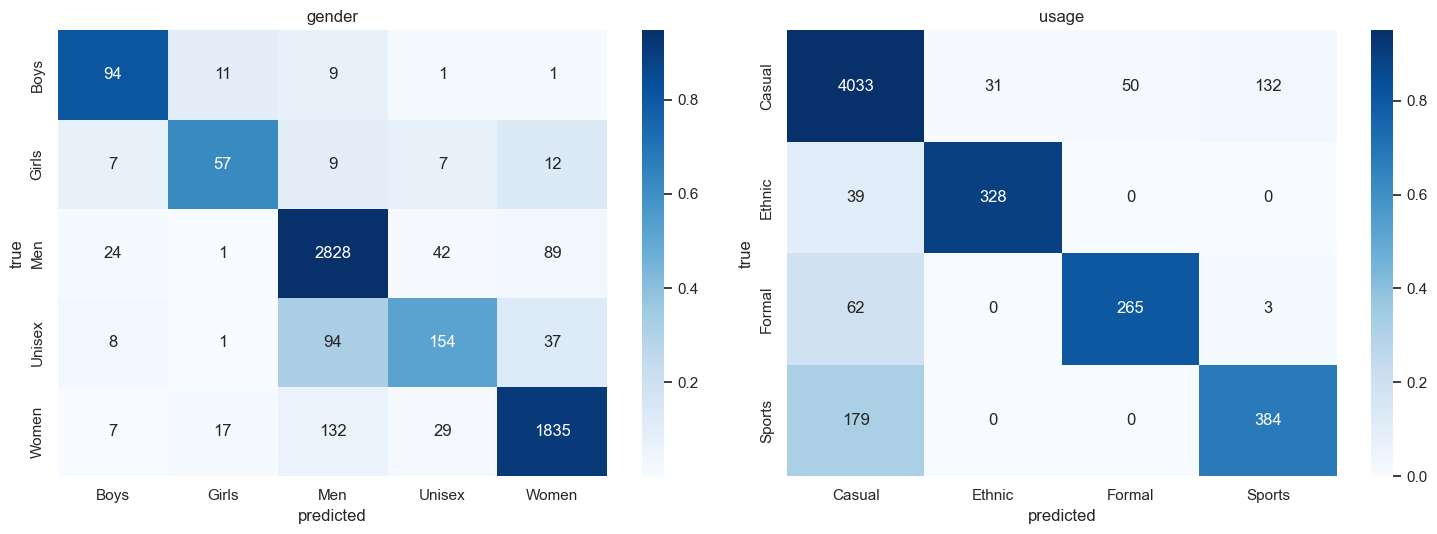

In [23]:
# ============================================
# CELL 22 - Per-class report and confusion matrices
# ============================================

for target in CONFIG["targets"]:
    print("=" * 60); print(target.upper()); print("=" * 60)
    print(classification_report(test_predictions[target]["true"],
                                test_predictions[target]["pred"],
                                target_names=class_names[target],
                                zero_division=0, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, target in zip(axes, CONFIG["targets"]):
    matrix = confusion_matrix(test_predictions[target]["true"],
                              test_predictions[target]["pred"])
    normalised = matrix / matrix.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(normalised, annot=matrix, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names[target], yticklabels=class_names[target])
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(target)
plt.tight_layout(); plt.show()

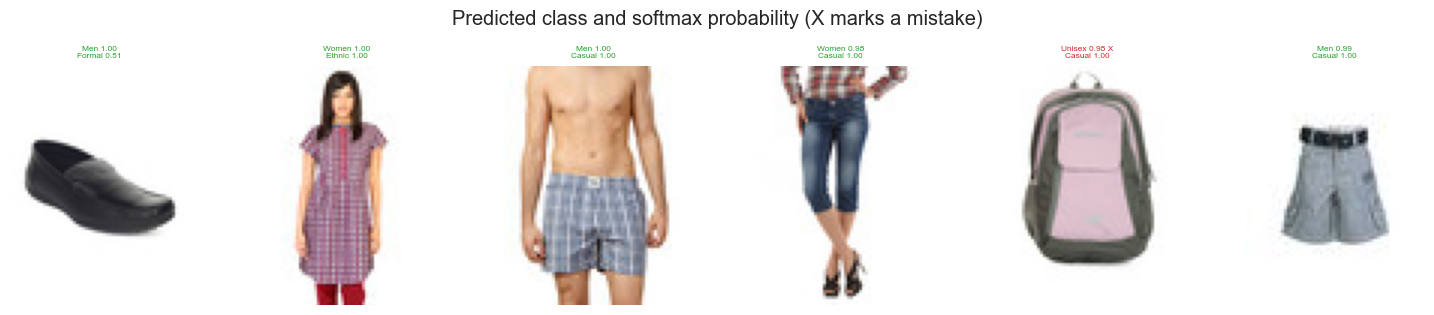

In [24]:
# ============================================
# CELL 23 - Softmax probabilities, as the notes describe
# ============================================

set_seed()
sample = test_df.sample(6, random_state=RANDOM_STATE)
loader = make_loader(sample, batch_size=6)
images, gender, usage = next(iter(loader))

FINAL_MODEL.eval()
with torch.no_grad():
    logits = FINAL_MODEL(images.to(DEVICE))

fig, axes = plt.subplots(1, 6, figsize=(15, 3.2))
for column, (ax, (_, row)) in enumerate(zip(axes, sample.iterrows())):
    ax.imshow(np.asarray(IMAGES[row["pos"]])); ax.axis("off")
    probabilities = {t: F.softmax(logits[t][column].float(), dim=0).cpu().numpy()
                     for t in CONFIG["targets"]}
    lines = []
    for target in CONFIG["targets"]:
        index = int(probabilities[target].argmax())
        correct = class_names[target][index] == row[target + "_label"]
        lines.append(f"{class_names[target][index]} "
                     f"{probabilities[target][index]:.2f}{'' if correct else ' X'}")
    ax.set_title("\n".join(lines), fontsize=6,
                 color="tab:green" if all("X" not in l for l in lines) else "tab:red")
plt.suptitle("Predicted class and softmax probability (X marks a mistake)")
plt.tight_layout(); plt.show()

In [25]:
# ============================================
# CELL 24 - Save
# ============================================

# Record the architecture so app/backend/services/task3_service.py can rebuild
# the network without hardcoding assumptions about how it was constructed.
architecture = {"shared_widths": [32, 64], "branch_widths": [128, 256],
                "hidden": 256, "dropout": 0.5} if FINAL_NAME == "EarlyBranch" else {}

torch.save({
    "state_dict": FINAL_MODEL.state_dict(),
    "model_name": FINAL_NAME,
    "architecture": architecture,
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    "channel_mean": CHANNEL_MEAN.tolist(),
    "channel_std": CHANNEL_STD.tolist(),
    "image_size_pil": list(IMAGE_SIZE_PIL),
    "test_metrics": {t: test_summary[t] for t in CONFIG["targets"]},
}, ARTIFACT_DIR / "task3_cnn_model.pt")

overview.to_csv(ARTIFACT_DIR / "architecture_comparison.csv", index=False)
branching.to_csv(ARTIFACT_DIR / "branching_comparison.csv", index=False)
comparison.to_csv(ARTIFACT_DIR / "flatten_vs_gap.csv", index=False)
activation.to_csv(ARTIFACT_DIR / "activation_comparison.csv", index=False)
final.to_csv(ARTIFACT_DIR / "final_test_metrics.csv", index=False)

summary_json = {
    "final_model": FINAL_NAME,
    "parameters": count_parameters(FINAL_MODEL),
    "test_gender_accuracy": round(test_summary["gender"]["accuracy"], 2),
    "test_gender_macro_f1": round(test_summary["gender"]["macro_f1"], 2),
    "test_usage_accuracy": round(test_summary["usage"]["accuracy"], 2),
    "test_usage_macro_f1": round(test_summary["usage"]["macro_f1"], 2),
    "test_exact_match": round(test_summary["exact_match"], 2),
    "baseline_gender_accuracy": round(BASELINE["gender"]["accuracy"], 2),
    "baseline_usage_accuracy": round(BASELINE["usage"]["accuracy"], 2),
}
with open(ARTIFACT_DIR / "task3_cnn_summary.json", "w") as handle:
    json.dump(summary_json, handle, indent=2)

print("Saved to", ARTIFACT_DIR)
for path in sorted(ARTIFACT_DIR.iterdir()):
    print("  ", path.name)

Saved to c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3_cnn
   activation_comparison.csv
   architecture_comparison.csv
   branching_comparison.csv
   final_test_metrics.csv
   flatten_vs_gap.csv
   task3_cnn_model.pt
   task3_cnn_summary.json


### For the report

**Architecture study.** Five landmark designs implemented and compared under one protocol,
with the reasoning behind each: LeNet's 5x5 kernels and tanh, AlexNet's ReLU and dropout, VGG's
stacked 3x3s, GoogLeNet's parallel kernel sizes, ResNet's skip connections. Cell 16 has the
numbers; the accuracy-versus-parameters plot shows which complexity was worth paying for.

**The multi-task question.** Cell 18 tests the claim in the course notes directly. Report the
`B - A` column: positive means early branching helped as predicted; near zero means the shared
filters served both tasks anyway at half the parameter cost. Either result is a finding,
provided the number is quoted.

**Flatten versus global average pooling.** Cell 19. Flatten keeps spatial position and costs
parameters; pooling discards position and regularises. At 60x80 with four pooling stages the
final map is small, so the two are closer than they would be at 224x224.

**Activation.** Cell 20 shows tanh against ReLU on an otherwise identical network — the clearest
single illustration of why the field moved on after 2012.

**Honest notes.** Every comparison shares one grouped split, one training loop and one metric.
Differences smaller than the +-noise floor in Cell 21 are reported as ties rather than ranked.